# Projeto Python IA: Inteligência Artificial e Previsões

### Case: Score de Crédito dos Clientes

Analisar os dados dos clientes de um banco e desenvolver um modelo capaz de ler as informações de cada cliente e classificar automaticamente o seu score de crédito em três categorias: Ruim, Ok ou Bom.

In [87]:
# Passo a passo
# Passo 1 - Importar a base de dados
import pandas as pd

df = pd.read_csv('clientes.csv')

display(df)

,id_cliente,mes,idade,profissao,salario_anual,num_contas,num_cartoes,juros_emprestimo,num_emprestimos,dias_atraso,...,idade_historico_credito,investimento_mensal,comportamento_pagamento,saldo_final_mes,score_credito,emprestimo_carro,emprestimo_casa,emprestimo_pessoal,emprestimo_credito,emprestimo_estudantil
0,3392,1,23.0,cientista,19114.12,3.0,4.0,3.0,4.0,3.0,...,265.0,21.465380,alto_gasto_pagamento_baixos,312.494089,Good,1,1,1,1,0
1,3392,2,23.0,cientista,19114.12,3.0,4.0,3.0,4.0,3.0,...,266.0,21.465380,baixo_gasto_pagamento_alto,284.629162,Good,1,1,1,1,0
2,3392,3,23.0,cientista,19114.12,3.0,4.0,3.0,4.0,3.0,...,267.0,21.465380,baixo_gasto_pagamento_medio,331.209863,Good,1,1,1,1,0
3,3392,4,23.0,cientista,19114.12,3.0,4.0,3.0,4.0,5.0,...,268.0,21.465380,baixo_gasto_pagamento_baixo,223.451310,Good,1,1,1,1,0
4,3392,5,23.0,cientista,19114.12,3.0,4.0,3.0,4.0,6.0,...,269.0,21.465380,alto_gasto_pagamento_medio,341.489231,Good,1,1,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,37932,4,25.0,mecanico,39628.99,4.0,6.0,7.0,2.0,23.0,...,378.0,24.028477,alto_gasto_pagamento_alto,479.866228,Poor,1,0,0,0,1
99996,37932,5,25.0,mecanico,39628.99,4.0,6.0,7.0,2.0,18.0,...,379.0,24.028477,alto_gasto_pagamento_medio,496.651610,Poor,1,0,0,0,1
99997,37932,6,25.0,mecanico,39628.99,4.0,6.0,7.0,2.0,27.0,...,380.0,24.028477,alto_gasto_pagamento_alto,516.809083,Poor,1,0,0,0,1
99998,37932,7,25.0,mecanico,39628.99,4.0,6.0,7.0,2.0,20.0,...,381.0,24.028477,baixo_gasto_pagamento_alto,319.164979,Standard,1,0,0,0,1


In [88]:
# Passo 2 - Preparar a base de dados para a Inteligência Artificial
display(df.info())

# LabelEncoder
from sklearn.preprocessing import LabelEncoder

# profissao
label_profissao = LabelEncoder()
df['profissao'] = label_profissao.fit_transform(df['profissao'])

# mix_credito
label_mix_credito = LabelEncoder()
df['mix_credito'] = label_mix_credito.fit_transform(df['mix_credito'])

# comportamento_pagamento
label_comportamento_pagamento = LabelEncoder()
df['comportamento_pagamento'] = label_comportamento_pagamento.fit_transform(df['comportamento_pagamento'])

display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 25 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   id_cliente                100000 non-null  int64  
 1   mes                       100000 non-null  int64  
 2   idade                     100000 non-null  float64
 3   profissao                 100000 non-null  object 
 4   salario_anual             100000 non-null  float64
 5   num_contas                100000 non-null  float64
 6   num_cartoes               100000 non-null  float64
 7   juros_emprestimo          100000 non-null  float64
 8   num_emprestimos           100000 non-null  float64
 9   dias_atraso               100000 non-null  float64
 10  num_pagamentos_atrasados  100000 non-null  float64
 11  num_verificacoes_credito  100000 non-null  float64
 12  mix_credito               100000 non-null  object 
 13  divida_total              100000 non-null  fl

None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 25 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   id_cliente                100000 non-null  int64  
 1   mes                       100000 non-null  int64  
 2   idade                     100000 non-null  float64
 3   profissao                 100000 non-null  int64  
 4   salario_anual             100000 non-null  float64
 5   num_contas                100000 non-null  float64
 6   num_cartoes               100000 non-null  float64
 7   juros_emprestimo          100000 non-null  float64
 8   num_emprestimos           100000 non-null  float64
 9   dias_atraso               100000 non-null  float64
 10  num_pagamentos_atrasados  100000 non-null  float64
 11  num_verificacoes_credito  100000 non-null  float64
 12  mix_credito               100000 non-null  int64  
 13  divida_total              100000 non-null  fl

None

In [89]:
# y -> é a coluna da base de dados que eu quero prever
y = df['score_credito']

# x -> as colunas da base de dados que eu vou usar pra fazer a previsão
x = df.drop(columns=['score_credito', 'id_cliente'])

# separar em dados de treino e dados de teste
from sklearn.model_selection import train_test_split

x_treino, x_teste, y_treino, y_teste = train_test_split(x, y, test_size=0.3)



C:\Users\henri\AppData\Local\Temp\ipykernel_7576\861499462.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importancias.Importancia, y=importancias.index, palette='viridis')


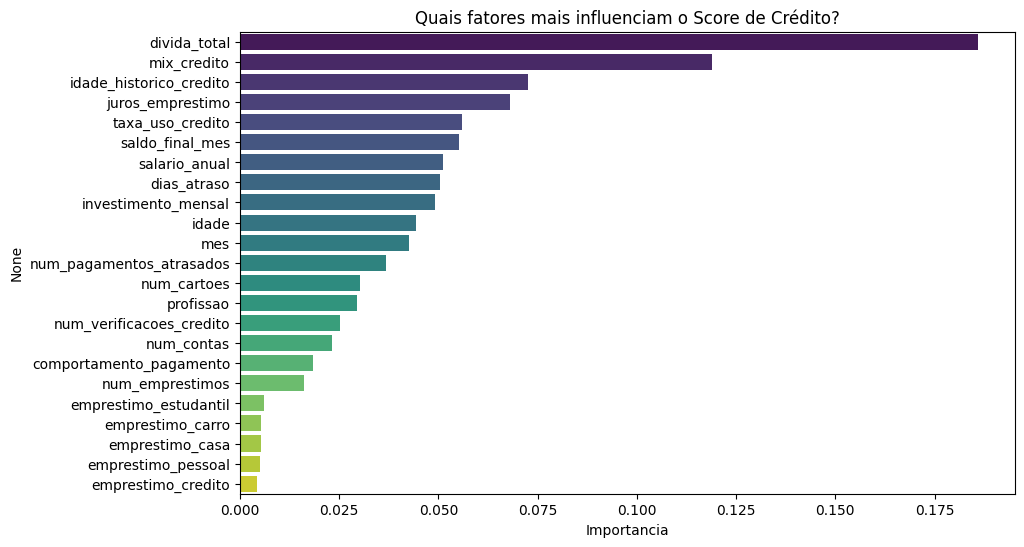

In [ ]:
# Passo 3 - Treinar a Inteligência Artificial -> 
# Criar o modelo: Nota de crédito: Boa, Ok, Ruim

# importar a IA
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

# criar a IA
modelo_arvoredecisao = DecisionTreeClassifier()
modelo_knn = KNeighborsClassifier()

# treinar a IA
modelo_arvoredecisao.fit(x_treino, y_treino)
modelo_knn.fit(x_treino, y_treino)

import matplotlib.pyplot as plt
import seaborn as sns

# Criando um DataFrame com as importâncias
importancias = pd.DataFrame(modelo_arvoredecisao.feature_importances_, x_treino.columns, columns=['Importancia'])
importancias = importancias.sort_values(by='Importancia', ascending=False)

# Gerando o gráfico
plt.figure(figsize=(10, 6))
sns.barplot(x=importancias.Importancia, y=importancias.index, palette='viridis')
plt.title('Quais fatores mais influenciam o Score de Crédito?')
plt.show()


0.7411

0.7378

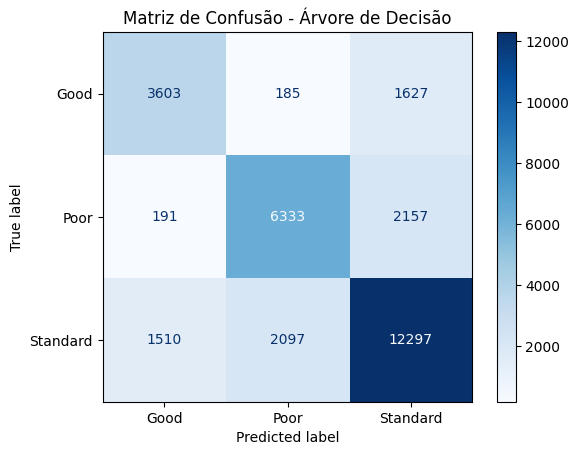

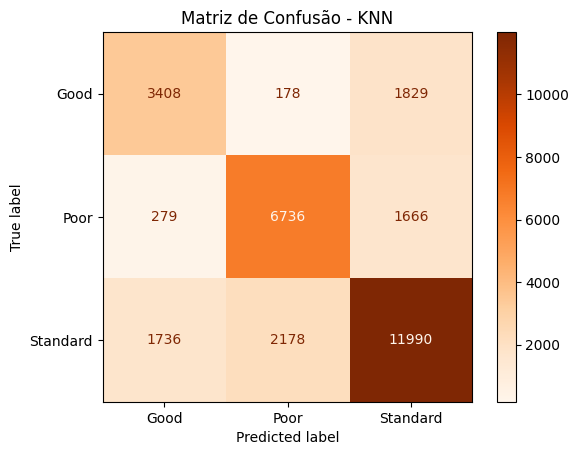

In [92]:
# Passo 4 - Escolher qual o melhor modelo
pred_arvoredecisao = modelo_arvoredecisao.predict(x_teste)
pred_knn = modelo_knn.predict(x_teste)

# acurácia
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
display(accuracy_score(y_teste, pred_arvoredecisao))
display(accuracy_score(y_teste, pred_knn))

# matriz de confusão
cm_arvoredecisao = confusion_matrix(y_teste, pred_arvoredecisao)
cm_knn = confusion_matrix(y_teste, pred_knn)

disp_arvoredecisao = ConfusionMatrixDisplay(confusion_matrix=cm_arvoredecisao, display_labels=modelo_arvoredecisao.classes_)
disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=modelo_knn.classes_)

disp_arvoredecisao.plot(cmap='Blues')
plt.title('Matriz de Confusão - Árvore de Decisão')
plt.show()

disp_knn.plot(cmap='Oranges')
plt.title('Matriz de Confusão - KNN')
plt.show()

In [93]:
# Passo 5 - Usar o melhor modelo para fazer previsão de novos clientes

# importar os novos clientes para fazer a previsao
novos_clientes = pd.read_csv('novos_clientes.csv')

# profissao
novos_clientes['profissao'] = label_profissao.transform(novos_clientes['profissao'])

# mix_credito
novos_clientes['mix_credito'] = label_mix_credito.transform(novos_clientes['mix_credito'])

# comportamento_pagamento
novos_clientes['comportamento_pagamento'] = label_comportamento_pagamento.transform(novos_clientes['comportamento_pagamento'])

# usar o modelo para fazer a previsão
previsao_novos_clientes = modelo_arvoredecisao.predict(novos_clientes)
display(previsao_novos_clientes)

array(['Poor', 'Poor', 'Standard'], dtype=object)